In [1]:
from sklearn import preprocessing
from data.FlagsRegression.dataset import load_dataset
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fclusterdata
import pickle
import matplotlib
from sklearn.metrics.pairwise import pairwise_distances
import time
import networkx as nx
from data.FlagsRegression.dataset import DatasetGenerator
from tqdm import tqdm

In [2]:
dataset_generator = DatasetGenerator(path='/home/dsalami/dataset/aggregated/pickle_2019-05-13-on7_2min.pkl', split_by='AP ID',
                                         train_ratio=100, test_ratio=16,
                                         lookback=60, scaler_range=(1, 2),
                                         steps=15, random_seed=1111)

 * Total data set samples: 12622684
      - APs for training/validation: ['7-1651', '7-933', '7-324', '7-3838', '7-2551', '7-2294', '7-199', '7-662', '7-4132', '7-864', '7-1642', '7-1899', '7-3973', '7-701', '7-2559', '7-2540', '7-40', '7-2507', '7-178', '7-2864', '7-2937', '7-640', '7-460', '7-496', '7-1022', '7-1002', '7-575', '7-1209', '7-3057', '7-4191', '7-3928', '7-238', '7-527', '7-621', '7-156', '7-1230', '7-678', '7-2016', '7-3085', '7-4170', '7-3428', '7-2658', '7-3031', '7-664', '7-846', '7-1071', '7-2815', '7-2409', '7-783', '7-4010', '7-3701', '7-4150', '7-3141', '7-654', '7-757', '7-3823', '7-1058', '7-515', '7-1730', '7-2059', '7-1040', '7-3140', '7-2076', '7-2810', '7-2352', '7-101', '7-742', '7-274', '7-2421', '7-1536', '7-4015', '7-1125', '7-2727', '7-3284', '7-877', '7-162', '7-2474', '7-2486', '7-1443', '7-1180', '7-2785', '7-4269', '7-3626', '7-3025', '7-3747', '7-3131', '7-3122', '7-735', '7-2311', '7-4299', '7-3060', '7-298', '7-182', '7-3569', '7-393', '7-4007',

In [3]:
train_data, train_target, train_ap = dataset_generator.getSplit('train')
train_data, train_target, train_ap = np.array(train_data), np.array(train_target), np.array(train_ap)
aps = np.unique(train_ap)
distances = {}

In [4]:
# Calculates kl divergence of two gmms
def gmm_kl(gmm_p, gmm_q, n_samples=10**5):
    X, _ = gmm_p.sample(n_samples)
    log_p_X = gmm_p.score_samples(X)
    log_q_X = gmm_q.score_samples(X)
    return log_p_X.mean() - log_q_X.mean()

def gmm_js(gmm_p, gmm_q, n_samples=10**5):
    X, _ = gmm_p.sample(n_samples)
    log_p_X = gmm_p.score_samples(X)
    log_q_X = gmm_q.score_samples(X)
    log_mix_X = np.logaddexp(log_p_X, log_q_X)

    Y, _ = gmm_q.sample(n_samples)
    log_p_Y = gmm_p.score_samples(Y)
    log_q_Y = gmm_q.score_samples(Y)
    log_mix_Y = np.logaddexp(log_p_Y, log_q_Y)

    return (log_p_X.mean() - (log_mix_X.mean() - np.log(2))
            + log_q_Y.mean() - (log_mix_Y.mean() - np.log(2))) / 2


In [5]:
with open('100-distances.pkl', 'rb') as inp:
    distances = pickle.load(inp)
def cluster_distance(i_p, i_q):
    p, q = aps[int(i_p[0])], aps[int(i_q[0])]
    key = ','.join(sorted([p, q]))
    if key in distances:
        print('Hit the cache!')
        return distances[key]
    distance = gmm_js(gmms[p], gmms[q])
    distances[key] = distance
    print(f'Calculating distance for {int(i_p[0])} and {int(i_q[0])}')
    return distance

In [6]:
gmms = {}
gmm_parameters = []
for i in tqdm(list(range(len(aps)))):
    original_data = train_target[train_ap == aps[i]][:, 0]
    gmms[aps[i]] = GaussianMixture(n_components=10, random_state=0).fit(original_data.reshape(-1, 1))
    gmm_parameters.append([np.array(gmms[aps[i]].means_).squeeze(), np.array(gmms[aps[i]].covariances_).squeeze()])
gmm_parameters = np.array(gmm_parameters)

100%|██████████| 100/100 [00:28<00:00,  3.54it/s]


In [8]:
start = time.time()
distance_matrix = pairwise_distances(np.array(range(len(aps))).reshape(-1, 1), metric=cluster_distance, n_jobs=10)
end = time.time()
print(end - start)
with open('100-distances.pkl', 'wb') as handle:
    pickle.dump(distances, handle, protocol=pickle.HIGHEST_PROTOCOL)

Calculating distance for 0 and 30
Calculating distance for 0 and 0
Calculating distance for 0 and 70
Calculating distance for 0 and 40
Calculating distance for 0 and 60
Calculating distance for 0 and 90
Calculating distance for 0 and 80
Calculating distance for 0 and 50
Calculating distance for 0 and 10
Calculating distance for 0 and 20
Calculating distance for 0 and 81
Calculating distance for 0 and 1
Calculating distance for 0 and 91
Calculating distance for 0 and 61
Calculating distance for 0 and 41
Calculating distance for 0 and 31
Calculating distance for 0 and 51
Calculating distance for 0 and 71
Calculating distance for 0 and 21
Calculating distance for 0 and 11
Calculating distance for 0 and 92
Calculating distance for 0 and 62
Calculating distance for 0 and 2
Calculating distance for 0 and 72
Calculating distance for 0 and 82
Calculating distance for 0 and 32
Calculating distance for 0 and 12
Calculating distance for 0 and 22
Calculating distance for 0 and 42
Calculating dista

In [35]:
start = time.time()
fclust1 = fclusterdata(np.array(range(len(aps))).reshape(-1, 1), .1, metric=cluster_distance)
end = time.time()
print(end - start)

Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the ca

In [31]:
clusters = np.array(fclust1)
for cluster in clusters:
    print(f'{cluster}: {(clusters == cluster).sum()}')

0: 1
1: 1
2: 37
3: 1
4: 1
2: 37
5: 1
2: 37
2: 37
6: 1
7: 1
2: 37
8: 1
9: 1
2: 37
10: 1
11: 1
2: 37
2: 37
12: 1
2: 37
13: 1
2: 37
2: 37
2: 37
14: 1
2: 37
2: 37
15: 1
2: 37
2: 37
16: 1
2: 37
17: 1
18: 1
19: 3
2: 37
20: 1
21: 1
22: 2
2: 37
23: 1
2: 37
24: 1
25: 1
22: 2
26: 1
2: 37
27: 1
28: 1
2: 37
19: 3
29: 1
2: 37
2: 37
30: 1
31: 1
2: 37
32: 1
19: 3
33: 1
34: 1
35: 1
36: 1
37: 1
38: 1
2: 37
2: 37
39: 1
40: 1
41: 1
42: 1
43: 1
44: 1
45: 1
2: 37
46: 1
47: 1
2: 37
2: 37
48: 1
2: 37
2: 37
49: 1
50: 1
2: 37
2: 37
51: 1
52: 1
53: 1
2: 37
54: 1
55: 1
56: 1
2: 37
57: 1
58: 1
59: 1
2: 37
60: 1


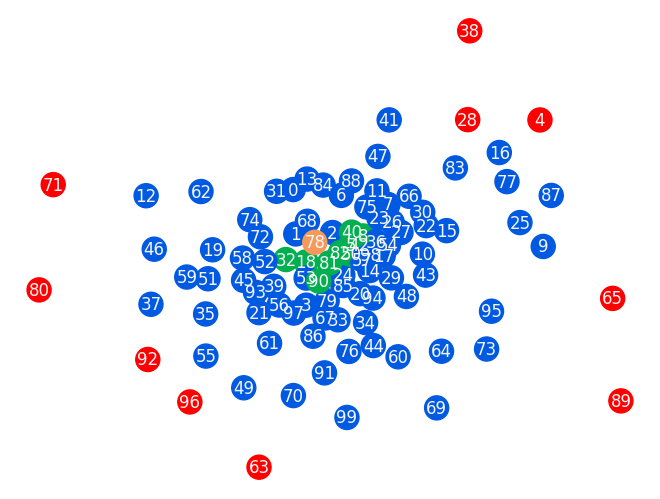

In [6]:
distanceMatrix = np.zeros((100, 100))
for i in range(len(aps)):
    for j in range(len(aps)):
        p, q = aps[i], aps[j]
        key = ','.join(sorted([p, q]))
        if i == j:
            distanceMatrix[i][j] = 0
        else:
            distanceMatrix[i][j] = distances[key]
G = nx.from_numpy_array(distanceMatrix)
pos = nx.kamada_kawai_layout(G)
colors = np.array(['#005ae1'] * len(aps))
colors[78] = '#f6995b'
colors[sorted(range(len(distanceMatrix[78])), key=lambda k: distanceMatrix[78][k], reverse=True)[:10]] = '#ff0000'
colors[sorted(range(len(distanceMatrix[78])), key=lambda k: distanceMatrix[78][k])[1:11]] = '#00b050'
nx.draw(G, node_color=colors, pos=pos, with_labels=True, edgelist=[], font_color='whitesmoke')
plt.savefig('grouping.png')

In [7]:
print(f'Target AP: {aps[78]}')
print(f'First experiment APs: {aps[sorted(range(len(distanceMatrix[78])), key=lambda k: distanceMatrix[78][k])[1:11]]}')
print(f'Second experiment APs: {aps[sorted(range(len(distanceMatrix[78])), key=lambda k: distanceMatrix[78][k], reverse=True)[:10]]}')

Target AP: 7-4299
First experiment APs: ['7-1071' '7-2815' '7-496' '7-515' '7-3060' '7-1209' '7-2785' '7-182'
 '7-2507' '7-678']
Second experiment APs: ['7-2727' '7-1058' '7-4010' '7-664' '7-481' '7-3747' '7-2409' '7-3838'
 '7-735' '7-846']


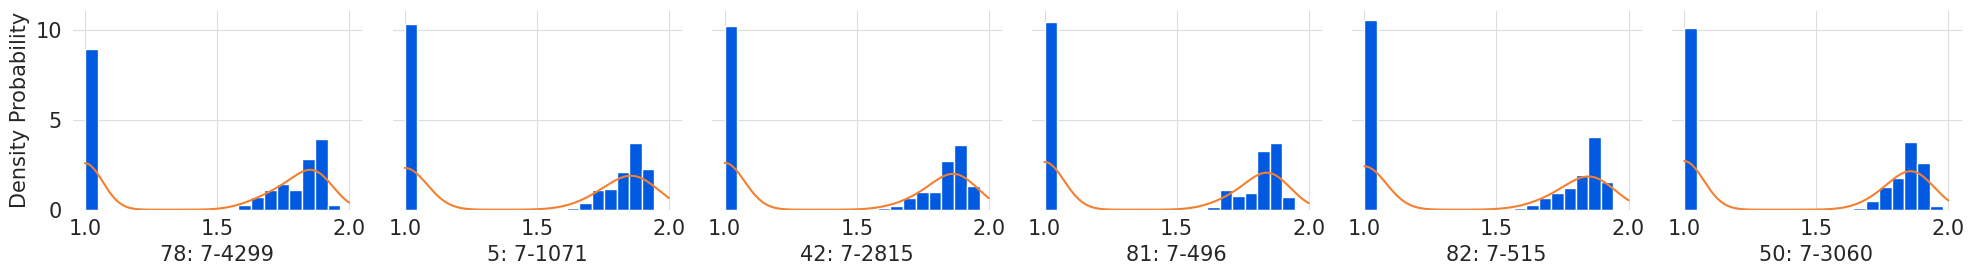

In [14]:
font = {'size'   : 15}
matplotlib.rc('font', **font)
matplotlib.rcParams['grid.color'] = '#dcddde'

aps_to_plot = [78]
aps_to_plot.extend(sorted(range(len(distanceMatrix[78])), key=lambda k: distanceMatrix[78][k])[1:6])
fig, axs = plt.subplots(1, len(aps_to_plot), sharey=True, tight_layout=True, figsize=(20, 3))
n_bins = 20
xx = np.linspace(1, 2, 1000)
for i, ap in enumerate(aps_to_plot):
    axs[i].hist(train_target[train_ap == aps[ap]][:, 0], bins=n_bins, density=True, color='#005ae1')
    kde0 = stats.gaussian_kde(train_target[train_ap == aps[ap]][:, 0])
    axs[i].plot(xx, kde0(xx), color='#f47f31')
    if i == 0:
        axs[i].set_ylabel('Density Probability')
    axs[i].set_xlabel(f'{ap}: {aps[ap]}')
    axs[i].set_facecolor((1, 1, 1))

plt.savefig('similar_aps.png')

In [40]:
distance_matrix = np.clip(distanceMatrix, a_min = 0, a_max = np.inf)
from sklearn.cluster import DBSCAN

clustering = DBSCAN(metric='precomputed', eps=0.1, min_samples=3)
clustering.fit(distance_matrix)
fclust1 = clustering.labels_

In [25]:
from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters=2, random_state=1, metric='precomputed').fit(distance_matrix)
print(kmedoids.labels_)
fclust1 = kmedoids.labels_

[1 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0
 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1
 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]


# How much data we need for an accurate pairwise distance calculation?

In [39]:
distances_from_full_gmm = {}
for i in tqdm(list(range(len(aps)))):
    original_data = train_target[train_ap == aps[i]][:, 0].reshape(-1, 1)
    full_gmm = GaussianMixture(n_components=10, random_state=0).fit(original_data)
    distances_from_full_gmm[i] = []
    for j in list(range(5, 100, 5)):
        sampled_indices = np.random.choice(list(range(len(original_data))), (j * len(original_data)) // 100, replace=False)
        if len(sampled_indices) < 5:
            distance = -1
        elif len(sampled_indices) < 10:
            distance = gmm_js(full_gmm, GaussianMixture(n_components=len(sampled_indices), random_state=0).fit(original_data[sampled_indices, :]))
        else:
            distance = gmm_js(full_gmm, GaussianMixture(n_components=10, random_state=0).fit(original_data[sampled_indices, :]))
        distances_from_full_gmm[i].append(distance)
    distances_from_full_gmm[i].append(0)

 37%|███▋      | 37/100 [07:06<11:24, 10.87s/it]/home/dsalami/.virtualenvs/load prediction/lib/python3.8/site-packages/sklearn/mixture/_base.py:116: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  cluster.KMeans(
/home/dsalami/.virtualenvs/load prediction/lib/python3.8/site-packages/sklearn/mixture/_base.py:116: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  cluster.KMeans(
/home/dsalami/.virtualenvs/load prediction/lib/python3.8/site-packages/sklearn/mixture/_base.py:116: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  cluster.KMeans(
/home/dsalami/.virtualenvs/load prediction/lib/python3.8/site-packages/sklearn/mixture/_base.py:116: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate p

In [45]:
x = list(range(5, 100, 5))
x.append(100)
x = np.array(x)

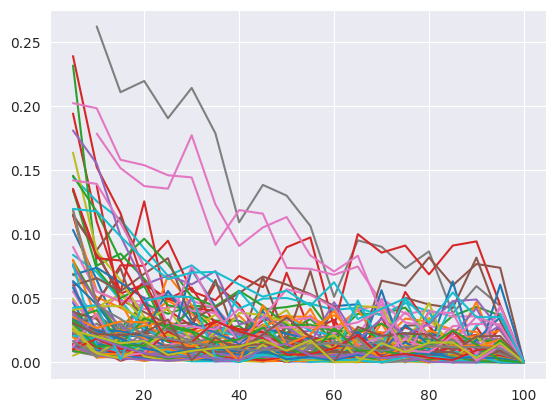

In [50]:
for i in range(100):
    y = np.array(distances_from_full_gmm[i])
    indices_to_keep = y >= 0
    plt.plot(x[indices_to_keep], y[indices_to_keep])  # Plot the chart
plt.show() 

In [61]:
mean = []
std = []
for i in range(len(distances_from_full_gmm[0])):
    values = []
    for ap in list(range(len(aps))):
        value = distances_from_full_gmm[ap][i]
        if value >= 0:
            values.append(value)
    mean.append(np.mean(values))
    std.append(np.std(values))
mean = np.array(mean)
std = np.array(std)

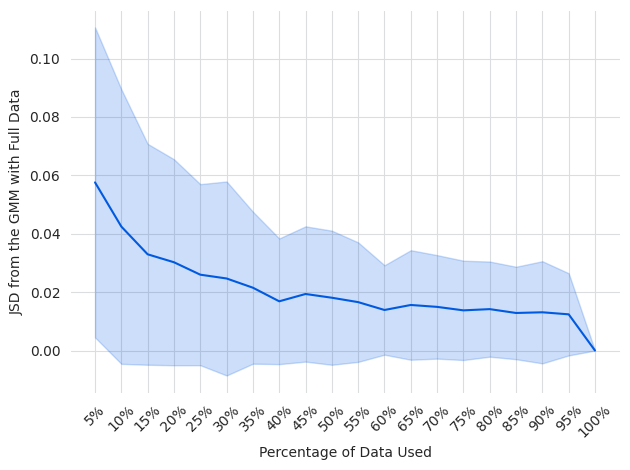

In [88]:
matplotlib.rcParams['grid.color'] = '#dcddde'
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(x, mean, color='#005ae1')
plt.fill_between(x, mean - std, mean + std, alpha=0.2, color='#005ae1')
plt.ylabel('JSD from the GMM with Full Data')
plt.xlabel('Percentage of Data Used')
plt.xticks(ticks=x, labels=['{}%'.format(label) for label in x], rotation=45)
ax.set_facecolor((1, 1, 1))
plt.tight_layout()
plt.savefig('data_needed.png')
plt.show()

In [22]:
data = {}
random_ap = aps[np.random.randint(0, 100)]
original_data = train_target[train_ap == random_ap][:, 0].reshape(-1, 1)
for i in tqdm(list(range(1, 11))):
    data[i] = []
    for _ in list(range(10)):
        sampled_indices = np.random.choice(list(range(len(original_data))), (i * 10 * len(original_data)) // 100, replace=False)
        data[i].append(original_data[sampled_indices, :])

100%|██████████| 10/10 [00:00<00:00, 96.63it/s]

865
865
865
865
865
865
865
865
865
865
1730
1730
1730
1730
1730
1730
1730
1730
1730
1730
2596
2596
2596
2596
2596
2596
2596
2596
2596
2596
3461
3461
3461
3461
3461
3461
3461
3461
3461
3461
4327
4327
4327
4327
4327
4327
4327
4327
4327
4327
5192
5192
5192
5192
5192
5192
5192
5192
5192
5192
6057
6057
6057
6057
6057
6057
6057
6057
6057
6057
6923
6923
6923
6923
6923
6923
6923
6923
6923
6923
7788
7788
7788
7788
7788
7788
7788
7788
7788
7788
8654
8654
8654
8654
8654
8654
8654
8654
8654
8654


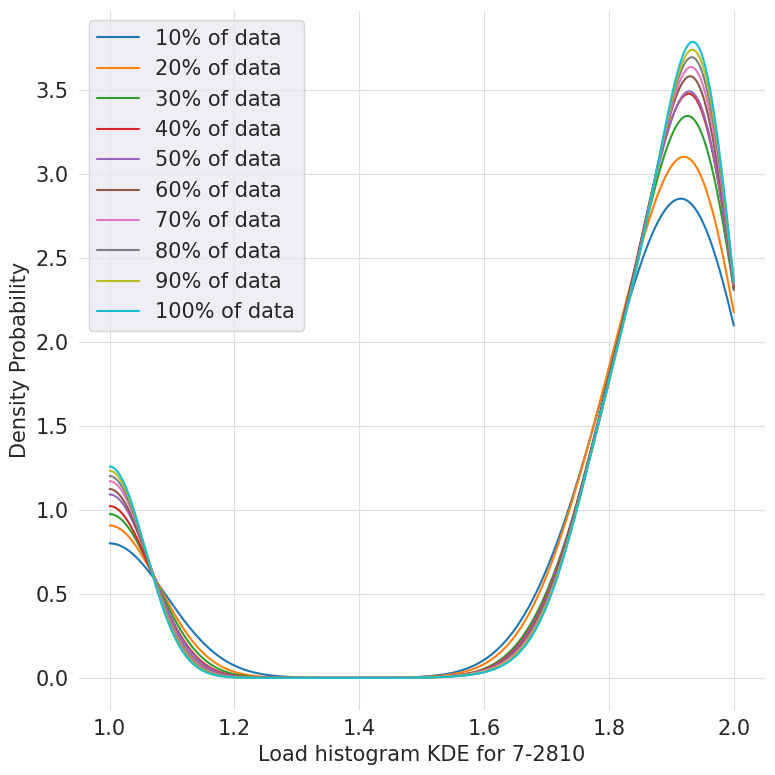

In [50]:
font = {'size'   : 15}
matplotlib.rc('font', **font)
matplotlib.rcParams['grid.color'] = '#dcddde'
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
n_bins = 20
xx = np.linspace(1, 2, 1000)
for i, key in enumerate(data.keys()):
    kde0 = stats.gaussian_kde(data[key][0].squeeze())
    
    plt.plot(xx, kde0(xx), label=f'{key * 10}% of data')

plt.ylabel('Density Probability')
plt.xlabel(f'Load histogram KDE for {random_ap}')
plt.legend()
ax.set_facecolor((1, 1, 1))
plt.tight_layout()
plt.savefig('data_needed_histogram_kde.png')

In [40]:
data[key][0].squeeze().shape

(865,)